In [57]:
from torch import optim
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../..')
from utils.dataset import PandasDataset
from utils.models import decode_ordinal_predictions

## Configuration

In [58]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths (this notebook lives in pos-propose/family/, so repo root is two levels up)
REPO_DIR   = '../..'                                   # pos-propose/family -> repo root
data_dir   = os.path.join(REPO_DIR, 'data')
images_dir = os.path.join(REPO_DIR, '..', 'bag_of_patches')

# Pre-trained B1 weights live in pos-propose/family/models/ (need the .pth extension)
model_path = 'models/family-b1.pth'

Using device: cuda


## Load Data with Entropy Filtering

In [59]:
df_test = pd.read_csv(os.path.join(data_dir, 'test.csv'))
df_test.columns = df_test.columns.str.strip()
print(f'Total records: {len(df_test)}')

# --- Noise cleaning: drop the noisiest images by difficulty score ---
def drop_missing(df):
    exists = df['image_id'].apply(lambda x: os.path.isdir(os.path.join(images_dir, str(x))))
    return df[exists].reset_index(drop=True)


df_test = drop_missing(df_test.reset_index(drop=True))
print(df_test['isup_grade'].value_counts().sort_index())

Total records: 1592
isup_grade
0    434
1    400
2    200
3    185
4    187
5    184
Name: count, dtype: int64


## Data Augmentation

In [60]:
val_transforms = None

## Create Datasets and DataLoaders

In [61]:
from utils.dataset import PandasOverlapDataset
# Create datasets
test_dataset   = PandasOverlapDataset(images_dir, df_test, transforms=val_transforms, overlap=0)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)
print(f"Test batches: {len(test_loader)}")

Test batches: 530


## Model Setup

In [62]:
# Model wrapper — MUST match the class used to train the family-* checkpoints
# (see efficientnet-b1-focal.ipynb). The head is LayerNorm -> Dropout -> Linear,
# which produces state_dict keys head.0.* / head.2.*. The EfficientNetApi in
# utils.models uses a different head (fully_connected.*) and will NOT load these
# weights.
class EfficientNetApi(nn.Module):
    """
    Generic torchvision EfficientNet (b0-b7) wrapper.

    Freezes the whole backbone, then unfreezes the last `unfreeze_blocks` feature
    blocks. The classifier is replaced by a plain multiclass head.
    """
    def __init__(self, model, output_dimensions, dropout_rate=0.4, unfreeze_blocks=2):
        super().__init__()
        self.model = model

        for p in self.model.parameters():
            p.requires_grad = False

        if unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        if isinstance(self.model.classifier, nn.Sequential):
            in_features = self.model.classifier[-1].in_features
        else:
            in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x):
        x = self.model(x)
        if x.ndim == 4:                 # safety for any non-pooled output
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x):
        return self.head(self.extract(x))

In [63]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Load Pre-trained Model Weights

In [64]:
# Load weights from the trained model
try:
    # Try importing strict weight loading
    try:
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    except TypeError:
        # Fallback for older torch versions
        model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Pre-trained model loaded successfully from {model_path}!")
except Exception as e:
    print(f"Could not load weights: {e}")

Pre-trained model loaded successfully from models/family-b1.pth!


# Save b1.csv

In [65]:
# model.eval()
# results = []

# with torch.no_grad():
#     for images, labels, img_ids in test_loader:
#         images = images.to(device)
#         logits = model(images)

#         preds = decode_ordinal_predictions(logits).cpu().numpy()
#         gts = labels.sum(dim=1).cpu().numpy()  # labels já são 0/1, soma direta = grade

#         for i in range(len(img_ids)):
#             image_id = img_ids[i].strip() if isinstance(img_ids[i], str) else img_ids[i]
#             grade_gt = int(gts[i])
#             pred_grade = int(preds[i])

#             results.append({
#                 'image_id': image_id,
#                 'grade_gt': grade_gt,
#                 'predicted': pred_grade
#             })

# df_results = pd.DataFrame(results)
# df_results.to_csv('b1.csv', index=False)

# print(f"CSV exportado: b1.csv ({len(df_results)} linhas)")
# df_results.head()

image: 2364e13161b373f7d463220e68eea803.png
True: 5 | Predicted: 1


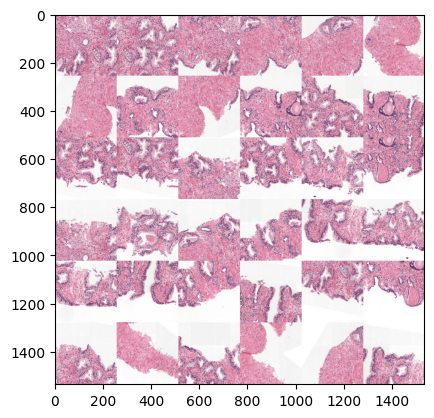

In [66]:
from PIL import Image
import os

# Select an image from the test set
sample_idx = 351 # indice otimo erro severo = 352 otimo = 58
image_id = test_dataset.dataframe.iloc[sample_idx]['image_id'].strip()
img_path = f"{images_dir}/{image_id}.png"

# Use skimage to load it exactly like PandasDataset
img_tensor, label_tensor, img_id  = test_dataset.__getitem__(sample_idx)
print(f"image: {img_id}.png")
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

plt.imshow(original_img_np)


model.eval()
with torch.no_grad():
    sample_tensor = img_tensor.unsqueeze(0).to(device)
    logit = model(sample_tensor)
    pred_grade = decode_ordinal_predictions(logit)[0].item()
    print(f"True: {int(sum(label_tensor))} | Predicted: {pred_grade}")

In [67]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt


class OrdinalGradCAM:
    """
    Grad-CAM para EfficientNet com cabeça de regressão ordinal.

    Melhorias em relação à versão anterior:
    - Alvo: features[-2] (último bloco MBConv) em vez do último Conv2d do modelo
      inteiro. O bloco MBConv produz gradientes espaciais mais ricos do que a
      conv 1×1 de expansão que vem depois (features[-1]).
    - Score: log(P(classe=predicted_grade)) derivado das probabilidades ordinais,
      em vez de somar logits brutos. Isso foca o gradiente na classe predita.
    - Hook de gradiente registrado no tensor de saída (output.register_hook),
      mais confiável do que register_full_backward_hook em containers Sequential.
    - Normalização por percentil (p2/p98) em vez de min-max, para suprimir
      ativações outlier que colapsariam o contraste nas regiões relevantes.
    """

    def __init__(self, model):
        self.model = model
        self.feature_maps = None
        self.gradient = None
        self._hook_handle = None

        # Alvo explícito: último bloco MBConv de EfficientNet
        target_layer = None
        try:
            target_layer = model.model.features[-2]
            print(f"Grad-CAM target: model.model.features[-2]  ({type(target_layer).__name__})")
        except AttributeError:
            pass

        if target_layer is None:
            # Fallback: último Conv2d encontrado por DFS
            for name, module in model.named_modules():
                if isinstance(module, torch.nn.Conv2d):
                    target_layer = module
                    print(f"Fallback Grad-CAM target: {name}")

        def _forward_hook(module, inp, output):
            self.feature_maps = output
            # Registra hook de gradiente diretamente no tensor de saída.
            # Só funciona quando gradientes estão habilitados.
            if output.requires_grad:
                output.register_hook(lambda g: setattr(self, "gradient", g))

        self._hook_handle = target_layer.register_forward_hook(_forward_hook)

    def __call__(self, x, predicted_grade):
        self.model.eval()
        self.feature_maps = None
        self.gradient = None

        # Forward pass com gradientes ativos para o hook de tensor funcionar
        logits = self.model(x)
        probs = torch.sigmoid(logits)   # (1, 5) limiares ordinais

        # Converte saídas ordinais em probabilidades por classe:
        #   P(grade=0) = 1 - σ(l0)
        #   P(grade=k) = σ(l_{k-1}) - σ(l_k)   para k = 1..4
        #   P(grade=5) = σ(l4)
        n = probs.shape[1]
        class_probs = torch.empty(n + 1, device=logits.device)
        class_probs[0] = 1.0 - probs[0, 0]
        for i in range(1, n):
            class_probs[i] = probs[0, i - 1] - probs[0, i]
        class_probs[n] = probs[0, n - 1]
        class_probs = class_probs.clamp(1e-7, 1.0)

        # Log-probabilidade: gradientes mais localizados do que soma de logits brutos
        score = torch.log(class_probs[predicted_grade])

        self.model.zero_grad()
        score.backward()

        if self.gradient is None or self.feature_maps is None:
            raise RuntimeError(
                "Hooks não capturaram dados. Garanta que torch.grad_enabled(True) "
                "está ativo antes de chamar este método."
            )

        # Grad-CAM: peso de cada canal = média espacial do seu gradiente
        weights = self.gradient.detach().mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam = F.relu((weights * self.feature_maps.detach()).sum(dim=1))    # (H, W)

        cam_np = cam.squeeze().cpu().numpy()

        # Normalização por percentil — robusto contra outliers de ativação
        lo, hi = np.percentile(cam_np, [2, 98])
        cam_np = np.clip((cam_np - lo) / (hi - lo + 1e-8), 0.0, 1.0)

        return cam_np

    def remove_hook(self):
        if self._hook_handle is not None:
            self._hook_handle.remove()


Grad-CAM target: model.model.features[-2]  (Sequential)


NameError: name 'orig2364e13161b373f7d463220e68eea803inal_img_np' is not defined

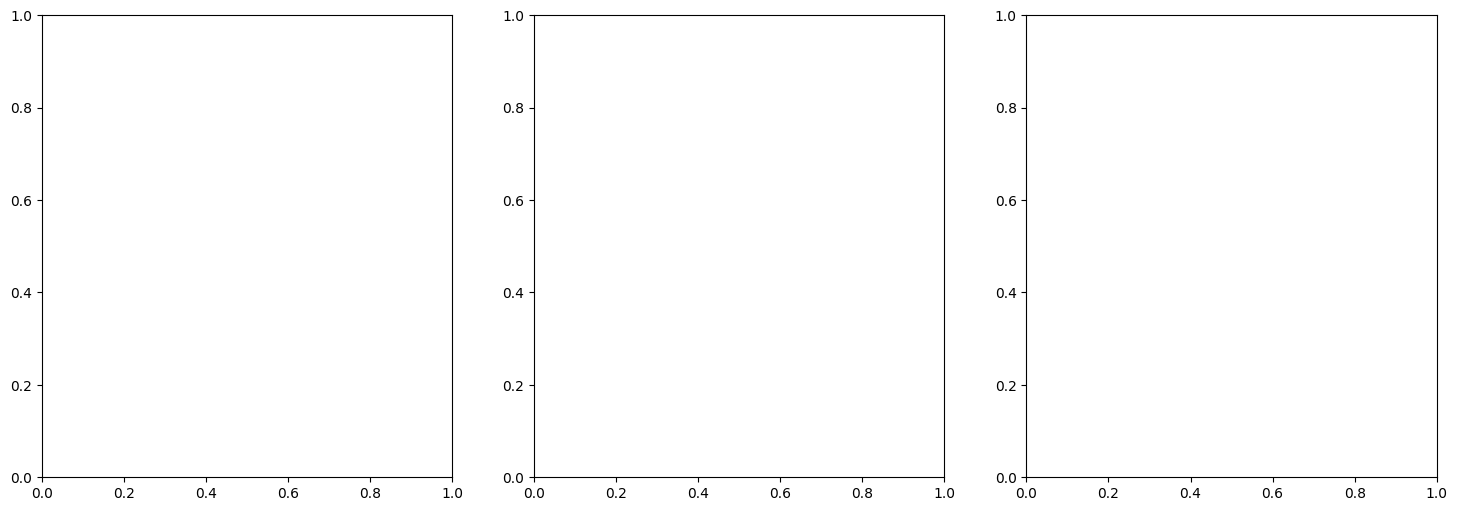

In [ ]:
# Instancia o Grad-CAM (hooks são registrados aqui)
grad_cam = OrdinalGradCAM(model)

torch.set_grad_enabled(True)
cam_mask = grad_cam(sample_tensor, pred_grade)
torch.set_grad_enabled(False)

original_img = img_tensor.numpy()
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

H, W = original_img_np.shape[:2]

# Upsampling bicúbico: bordas mais suaves do que o linear padrão
cam_resized = cv2.resize(cam_mask, (W, H), interpolation=cv2.INTER_CUBIC)
cam_resized = np.clip(cam_resized, 0.0, 1.0)

heatmap_bgr = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

# Alpha-blend: 55% original + 45% heatmap mantém detalhes do tecido visíveis
alpha = 0.55
overlay = np.clip(
    original_img_np.astype(np.float32) * alpha + heatmap_rgb.astype(np.float32) * (1 - alpha),
    0, 255
).astype(np.uint8)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title(f"Original\nGT: {int(sum(label_tensor))}  |  Pred: {pred_grade}", fontsize=13)
axes[0].axis("off")

axes[1].imshow(heatmap_rgb)
axes[1].set_title("Grad-CAM Heatmap\n(vermelho = regiões mais relevantes)", fontsize=13)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Grad-CAM Overlay", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
os.makedirs("logs", exist_ok=True)
plt.savefig("logs/gradcam_b1.png", dpi=300, bbox_inches="tight")
plt.show()

# Remove hooks para evitar acumulação em re-execuções
grad_cam.remove_hook()
